In [1]:
# Basic libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors  # Matplotlib color module

# PyTorch related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.init as init
from torch.utils.tensorboard import SummaryWriter
import torchvision
import torchvision.transforms as transforms

# Image processing libraries
from PIL import Image, ImageOps, ImageFilter
import cv2
from skimage import transform, data
from skimage.transform import resize
from scipy.ndimage import label, center_of_mass, distance_transform_edt
from scipy.optimize import curve_fit
from skimage.measure import regionprops
from scipy.interpolate import griddata

# 1、Load your HAADF-STEM image

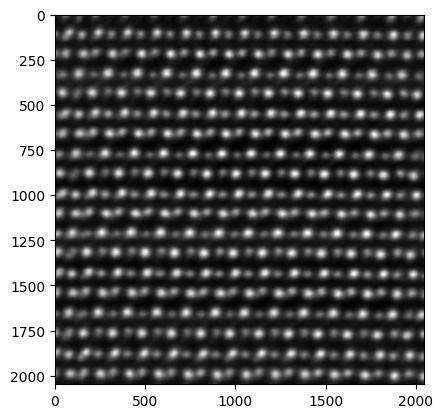

In [2]:
img_path = '673K_denoised.tif'  # change to your own image path
save_img_path = "673.jpg"       # define the output path

#visualization
denoise_frame_i = Image.open(img_path)
denoise_frame_i = denoise_frame_i.convert('L')
plt.imshow(denoise_frame_i,cmap='gray')
plt.show()

# 2、Load the model

In [3]:
class DoubleConV(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super(DoubleConV, self).__init__()
        #self.pad = nn.ReplicationPad2d(1)
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, padding_mode='replicate', bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, padding_mode='replicate', bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, X):
        return self.double_conv(X)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConV(in_channels, out_channels)
        )

    def forward(self, X):
        return self.maxpool(X)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super(Up, self).__init__()
        #bilinear
        self.up = nn.UpsamplingBilinear2d(scale_factor=2)
        self.conv = DoubleConV(in_channels, out_channels, in_channels//2)

    def forward(self, X1, X2):
        X1 = self.up(X1)
        #print(X2.size(),X1.size())
        if not (X2.size()[2] == X1.size()[2] or X2.size()[3] == X1.size()[3]):
            DetaX = X1.size()[2] - X2.size()[2]
            DetaY = X1.size()[3] - X2.size()[3]
            X2 = F.pad(X2, [DetaX // 2, DetaX - DetaX // 2,
                            DetaY // 2, DetaY - DetaY // 2], mode='replicate')
            print('there is different cat_size, and we let X2 the same as X1 atomatically')
        X = torch.cat([X2, X1], dim=1)
        return self.conv(X)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, X):
        return self.conv(X)

class Unet(nn.Module):
    def __init__(self, colordim=1, n_classes=2, drop=0, bilinear=True):
        super(Unet, self).__init__()
        self.colordim = colordim
        self.n_classes = n_classes

        self.inp = DoubleConV(colordim, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512,512)
        self.up1 = Up(1024, 256, bilinear)
        self.up2 = Up(512, 128, bilinear)
        self.up3 = Up(256, 64, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outp = OutConv(64, n_classes)
        self.dropout = nn.Dropout(drop)
        self._initialize_weights()

    def forward(self, X):
        X1 = self.inp(X)
        X2 = self.down1(X1)
        X3 = self.down2(X2)
        X4 = self.down3(X3)
        X4 = self.dropout(X4)
        X5 = self.down4(X4)
        X5 = self.dropout(X5)
        X = self.up1(X5, X4)
        X = self.up2(X, X3)
        X = self.up3(X, X2)
        X = self.up4(X, X1)
        out = self.outp(X)
        return out

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)
            if isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)

# 3、Atom identify

In [4]:
def pad_img(image, target_size):
    """Resize and pad image to the target size (256, 256) while maintaining aspect ratio."""
    iw, ih = image.size  # Original image width and height
    tw, th = target_size  # Target size (256, 256)

    # Calculate scale factor to maintain aspect ratio
    scale = min(tw / iw, th / ih)
    nw, nh = int(iw * scale), int(ih * scale)

    # Resize the image
    image = image.resize((nw, nh), Image.BILINEAR)

    # Create new background image and paste the resized image at the center
    new_image = Image.new("L", target_size)
    new_image.paste(image, ((tw - nw) // 2, (th - nh) // 2))

    return new_image, nw, nh

def pred(image, height_periodicity):
    """
    Cut the image into squares according to vertical periodicity and perform prediction.
    """
    old_image = image  # Backup original image

    # Initialize transforms
    transform1 = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])
    transform2 = transforms.ToPILImage()

    # Calculate block height in vertical direction
    box_height = image.height // height_periodicity
    box_size = box_height  # Square block size: box_size x box_size

    # Calculate proportional output width (not rounded)
    proportional_width = (image.width * height_periodicity * 256) / image.height

    # Round up width periodicity to ensure block alignment
    width_periodicity = int(np.ceil(proportional_width / 256))
    output_width = width_periodicity * 256  # Rounded output width
    output_height = height_periodicity * 256  # Output height

    # Initialize output image (including extra parts)
    output = Image.new('L', (output_width, output_height))

    # Loop through image blocks by width and height
    for i in range(width_periodicity):
        for j in range(height_periodicity):
            # Calculate current block coordinates
            left = i * box_size
            upper = j * box_height
            right = min((i + 1) * box_size, image.width)
            lower = (j + 1) * box_height

            # Crop image block
            image_ij = image.crop((left, upper, right, lower))

            # Pad block on right if width is less than box_size
            if image_ij.width < box_size:
                pad_width = box_size - image_ij.width
                image_ij = ImageOps.expand(image_ij, (0, 0, pad_width, 0), fill=0)

            # Resize or pad block to (256, 256)
            image_ij, nw, nh = pad_img(image_ij, (256, 256))

            # Convert to tensor and reshape
            image_ij = transform1(image_ij)
            image_ij = torch.reshape(image_ij, (1, 1, 256, 256))

            # Load U-Net model and predict
            model = Unet()
            model.load_state_dict(torch.load('model.pth')['model_state_dict'])
            model.eval()

            with torch.no_grad():
                output_ij = model(image_ij)

            # Get prediction and normalize
            output_ij = torch.argmax(output_ij, dim=1)
            output_ij = torch.reshape(output_ij, (256, 256)).float()
            output_ij = transform2(output_ij)  # Convert tensor back to PIL image

            # Crop extra padding
            crop_box = (
                (256 - nw) // 2, (256 - nh) // 2,
                256 - (256 - nw) // 2, 256 - (256 - nh) // 2
            )
            output_ij = output_ij.crop(crop_box)

            # Calculate paste position and paste predicted block
            paste_x = 256 * i
            paste_y = 256 * j
            output.paste(output_ij, (paste_x, paste_y))

    # Crop extra parts to keep correct aspect ratio
    final_width = int(proportional_width)  # Final width according to proportion
    output = output.crop((0, 0, final_width, output_height))

    return old_image, output

def visualize_images(original, predicted):
    """Visualize original and predicted images using Matplotlib."""
    plt.figure(figsize=(12, 6))

    # Display original image
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    # Display predicted image
    plt.subplot(1, 2, 2)
    plt.imshow(predicted, cmap='gray')
    plt.title("Predicted Image")
    plt.axis('off')

    # Show images
    plt.show()

#### 3.1、Segment the atoms

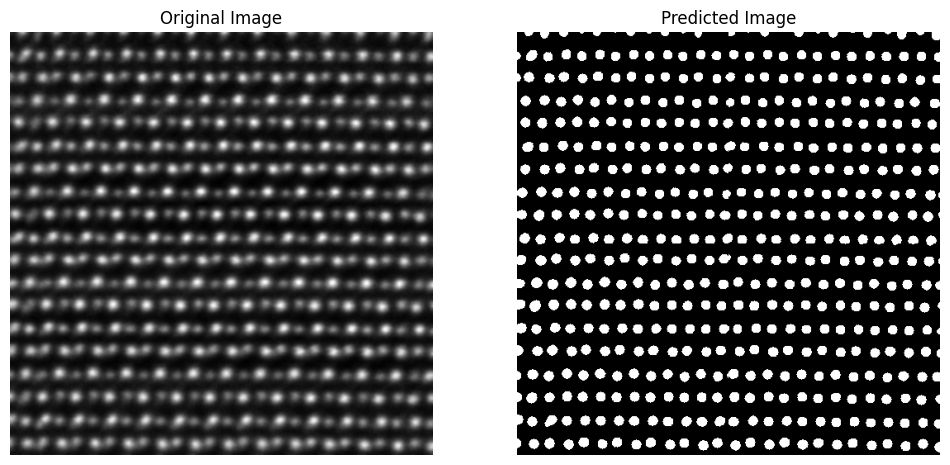

In [5]:
height_periodicity = 2  # Number of periodic blocks along the vertical direction

# Call the prediction function
_, output_image = pred(denoise_frame_i, height_periodicity)

# Visualize the original and predicted images
visualize_images(denoise_frame_i, output_image)

In [6]:
def resize_image_to_match(image, target_image):
    """Resize output_image to match the size of the reference image using nearest neighbor interpolation."""
    return image.resize(target_image.size, Image.NEAREST)

def crop_region(image, center, size=50):
    """
    Crop a square region from the image centered at the given coordinates.
    
    Args:
        image (PIL.Image): The source image.
        center (tuple): The center coordinate (y, x) for cropping.
        size (int): The length of the square region's side.
        
    Returns:
        PIL.Image: Cropped image region.
    """
    x, y = int(center[1]), int(center[0])
    half_size = size // 2
    return image.crop((x - half_size, y - half_size, x + half_size + 1, y + half_size + 1))

def process_images(image, output_image, filter_size=0.25, crop_size=15, visual=True):
    """
    Process labeled image regions to extract atom positions and peak intensities.
    
    Steps:
    1. Resize output_image to match image size.
    2. Label connected regions in the image.
    3. Extract region properties such as area and centroid.
    4. Filter regions by area threshold (retain regions with area >= average_area * filter_size).
    5. For each valid region, crop a local area from the original image and find the max intensity (peak).
    6. Optionally visualize cropped regions.
    
    Args:
        image (numpy.ndarray): Input image array.
        output_image (PIL.Image): Output segmentation or processed image.
        filter_size (float): Fraction of average area to use as threshold for filtering regions.
        crop_size (int): Size of the local square region to crop around each centroid.
        visual (bool): Whether to show cropped regions during processing.
    
    Returns:
        list of tuples: Each tuple contains ((x, y), peak_intensity) for detected atom positions.
    """
    
    # Resize output image to match input image size
    output_image = resize_image_to_match(output_image, image)

    # Label connected components in the input image
    labeled_image, num_features = label(output_image)

    # Extract region properties
    props = regionprops(labeled_image)

    areas = []
    centers = []

    for region in props:
        areas.append(region.area)
        centers.append(region.centroid)  # centroid as (y, x)

    areas = np.array(areas)
    centers = np.array(centers)

    average_area = np.mean(areas)

    # Filter centers by area threshold
    valid_centers = centers[areas >= (average_area * filter_size)]

    atom_positions = []  # List to store atom positions and peak intensities

    # Crop local regions and find peak intensities
    for idx, (y, x) in enumerate(valid_centers):
        cropped = crop_region(image, (y, x), size=crop_size)

        if (idx % 20 == 0) and visual:
            plt.imshow(cropped, cmap='gray')
            plt.title(f'Cropped region {idx}')
            plt.axis('off')
            plt.show()

        peak = np.mean(np.array(cropped))
        atom_positions.append(((x, y), peak))

    return atom_positions

def visualize_results(image, atom_positions):
    """
    Visualize detected atom positions on the original image and show peak intensity distribution.

    Parameters:
    - image: Original image (as a NumPy array or PIL Image)
    - atom_positions: List of tuples ((x, y), peak_value), where
                      (x, y) is the detected atom center and peak_value is the corresponding intensity.
    """
    plt.figure(figsize=(12, 6))  # Create a figure with specified size

    # --- Left subplot: display image with atom positions marked ---
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Detected Atoms")

    # Mark each detected atom position with a red 'X'
    peaks = []  # List to collect peak intensity values
    for (x, y), peak in atom_positions:
        plt.plot(x, y, 'rx', markersize=8)  # Mark atom center with red 'X'
        peaks.append(peak)  # Store peak intensity for histogram

    # --- Right subplot: display histogram of peak intensities ---
    plt.subplot(1, 2, 2)
    plt.hist(peaks, bins=20, color='blue', alpha=0.7)  # Plot histogram of peak intensities
    plt.title("Peak Intensity Distribution")
    plt.xlabel("Peak Height")
    plt.ylabel("Frequency")

    # Show the combined plot
    plt.show()

#### 3.2、Atom position

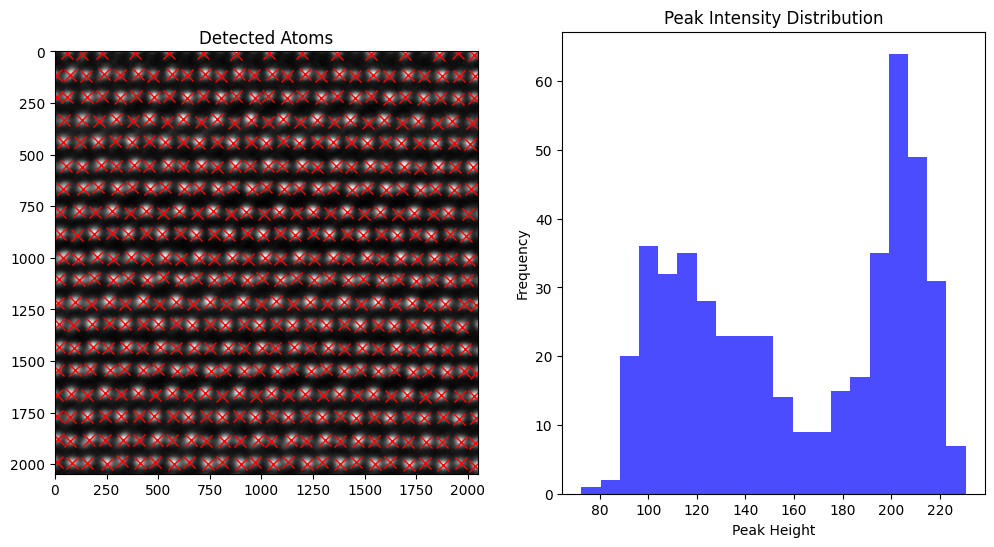

In [7]:
# Detect atomic positions and peak intensities from the image  
# Input: denoised image and predicted map; Output: list of [(x, y), peak_intensity]
atom_positions = process_images(denoise_frame_i, output_image, filter_size=1/4, crop_size=20, visual=False)

# Visualize atom positions and peak intensity distribution  
# Input: image and atom positions; Output: annotated image and histogram
visualize_results(denoise_frame_i, atom_positions)

In [8]:
def filter_atoms_by_peak(atom_positions, min_peak=80, max_peak=160):
    """Filter atoms whose peak values are within a specified range.
    Args:
        atom_positions: List of ((x, y), peak) tuples.
        min_peak: Minimum allowed peak value.
        max_peak: Maximum allowed peak value.
    Returns:
        Filtered list of atoms within the peak range.
    """
    return [
        (position, peak) for position, peak in atom_positions
        if min_peak <= peak <= max_peak
    ]

def calculate_nearest_neighbor_distances(atom_positions):
    """Calculate average nearest-neighbor distance between atoms.
    Args:
        atom_positions: List of ((x, y), peak) tuples.
    Returns:
        Average distance to the nearest neighbor.
    """
    distances = []
    n = len(atom_positions)
    for i in range(n):
        min_dist = float('inf')
        for j in range(n):
            if i != j:
                dist = np.linalg.norm(np.array(atom_positions[i][0]) - np.array(atom_positions[j][0]))
                if dist < min_dist:
                    min_dist = dist
        distances.append(min_dist)
    return np.mean(distances) if distances else 0

def remove_close_atoms(atom_positions, avg_nn_distance):
    # Sort atoms by peak value descending (keep higher peaks first)
    sorted_atoms = sorted(atom_positions, key=lambda x: x[1], reverse=True)
    
    kept_atoms = []

    while sorted_atoms:
        current_atom = sorted_atoms.pop(0)
        keep = True

        # Discard atoms too close to already kept atoms
        for kept_atom in kept_atoms:
            dist = np.linalg.norm(np.array(current_atom[0]) - np.array(kept_atom[0]))
            if dist < avg_nn_distance:
                keep = False
                break

        if keep:
            kept_atoms.append(current_atom)

    return kept_atoms


def mark_atoms_on_image(image, atom_positions, avg_nn_distance):
    """Draw atom positions and one distance reference circle on the image.
    Args:
        image: Input image (2D array).
        atom_positions: List of ((x, y), peak) tuples.
        avg_nn_distance: Radius for drawing a single circle for reference.
    """
    plt.figure(figsize=(8, 8))
    plt.imshow(image, cmap='gray')
    for (x, y), peak in atom_positions:
        plt.plot(x, y, 'rx', markersize=6)
        plt.text(x + 2, y + 2, f'{peak:.1f}', color='yellow', fontsize=6)
    
    # Draw a reference circle using the last atom
    circle = plt.Circle((x, y), radius=avg_nn_distance, color='cyan', fill=False, linewidth=1.5)
    plt.gca().add_patch(circle)

    plt.title("Filtered Atoms with Peak Values")
    plt.axis('off')
    plt.show()

#### 3.3、Filter Se atoms

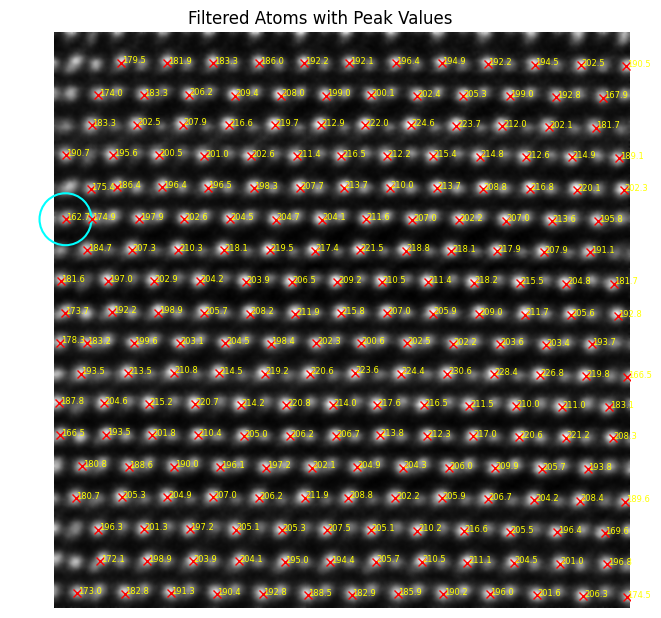

In [9]:
# Example: filter atoms by peak, remove close ones, and mark on image
filtered_atoms = filter_atoms_by_peak(atom_positions, min_peak=160, max_peak=255)  # Filter atoms by peak height
avg_nn_distance = calculate_nearest_neighbor_distances(filtered_atoms) / 1.2     # Calculate average nearest neighbor distance with adjustment
final_atoms = remove_close_atoms(filtered_atoms, avg_nn_distance)                 # Remove atoms too close to others

# Mark filtered atoms on the image
mark_atoms_on_image(denoise_frame_i, final_atoms, avg_nn_distance)

# 4、Phase identify

In [10]:
def calculate_angle_with_axis(O, P, axis='x'):
    """
    Calculate the angle between vector OP and the specified axis ('x', '-x', 'y', '-y').
    """
    vector = np.array(P) - np.array(O)
    
    if axis == 'x':
        reference_vector = np.array([1, 0])  # Horizontal axis
    elif axis == '-x':
        reference_vector = np.array([-1, 0])  # Horizontal axis
    elif axis == '-y':
        reference_vector = np.array([0, -1])  # Vertical axis
    elif axis == 'y':
        reference_vector = np.array([0, 1])  # Vertical axis
    else:
        raise ValueError("Axis must be 'x' or 'y'.")
    
    cos_angle = np.dot(vector, reference_vector) / (np.linalg.norm(vector) * np.linalg.norm(reference_vector))
    angle = np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))
    return angle

def calculate_angle_between_vectors(A, B, O):
    """
    Calculate the angle between vectors OA and OB, where O is the common vertex.
    """
    vector_OA = np.array(A) - np.array(O)
    vector_OB = np.array(B) - np.array(O)

    cos_theta = np.dot(vector_OA, vector_OB) / (
        np.linalg.norm(vector_OA) * np.linalg.norm(vector_OB)
    )
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    # return the angle
    angle = np.degrees(np.arccos(cos_theta))
    return angle

def find_nearest_atoms(O, final_atoms, avg_nn_distance):
    """
    Find nearest atoms A, B, C near O aligned roughly with x and y axes within avg_nn_distance.
    """
    candidates = [
        pos for pos, _ in final_atoms
        if np.linalg.norm(np.array(O) - np.array(pos)) <= avg_nn_distance and not np.allclose(pos, O)
    ]

    # Find atoms close to the -y direction (approximately vertical) as A
    y_candidates = [
        pos for pos in candidates
        if -30 <= calculate_angle_with_axis(O, pos, axis='-y') <= 30  # Limit within 30 degrees
    ]
    A = min(y_candidates, key=lambda pos: np.linalg.norm(np.array(O) - np.array(pos)), default=None)

    # Find atoms close to the +x direction (approximately horizontal) as B
    x_candidates = [
        pos for pos in candidates
        if -10 <= calculate_angle_with_axis(O, pos, axis='x') <= 10  # Limit within 10 degrees
    ]
    B = min(x_candidates, key=lambda pos: np.linalg.norm(np.array(O) - np.array(pos)), default=None)

    # Find atoms close to the -x direction (approximately horizontal) as C
    _x_candidates = [
        pos for pos in candidates
        if -10 <= calculate_angle_with_axis(O, pos, axis='-x') <= 10  # Limit within 10 degrees
    ]
    C = min(_x_candidates, key=lambda pos: np.linalg.norm(np.array(O) - np.array(pos)), default=None)

    return A, B, C

def visualize_single_atom_with_vectors(image, O, A, B, C, radius):
    """
    Visualize atom O and neighbors A, B, C with vectors and x/y axes on the image.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image, cmap='gray')

    ox, oy = O
    circle = plt.Circle((ox, oy), radius=radius, color='cyan', fill=False, linewidth=1.5)
    ax.add_patch(circle)
    ax.plot(ox, oy, 'ro', markersize=10, label='O (Selected)')

    # Draw dashed lines for x and y axes
    ax.axhline(oy, color='blue', linestyle='--', linewidth=1, label='x-axis')
    ax.axvline(ox, color='green', linestyle='--', linewidth=1, label='y-axis')

    # Draw vector OA (horizontal direction)
    if A:
        ax.plot(A[0], A[1], 'bo', markersize=8, label='A (x-direction)')
        ax.arrow(ox, oy, A[0] - ox, A[1] - oy, color='blue', head_width=5, length_includes_head=True)

    # Draw vectors OB and OC (vertical direction)
    if B:
        ax.plot(B[0], B[1], 'go', markersize=8, label='B (y-direction)')
        ax.arrow(ox, oy, B[0] - ox, B[1] - oy, color='green', head_width=5, length_includes_head=True)

    if C:
        ax.plot(C[0], C[1], 'mo', markersize=8, label='C (y-direction)')
        ax.arrow(ox, oy, C[0] - ox, C[1] - oy, color='magenta', head_width=5, length_includes_head=True)

    ax.legend(loc='upper right')
    plt.title("Visualization of Atom O with Nearest Neighbors and Axes")
    plt.axis('off')
    plt.show()

def extract_features(final_atoms, avg_nn_distance, visualize_atom_index=None, plt_feature=1):
    """
    Extract atoms with characteristic angles between neighbors; optionally visualize selected atoms.
    """
    features = []

    for idx, (O, _) in enumerate(final_atoms):
        A, B, C = find_nearest_atoms(O, final_atoms, avg_nn_distance)
        
        if A is not None:
            # Visualize selected atom and neighbors if enabled
            if (B is not None or C is not None) and plt_feature == 1:
                visualize_single_atom_with_vectors(denoise_frame_i, O, A, B, C, avg_nn_distance)
            if B is not None and C is not None:
                angle_AB = calculate_angle_between_vectors(A, B, O)
                angle_AC = calculate_angle_between_vectors(A, C, O)
                # Check if angles are within range, append smaller angle
                if 65 <= angle_AB <= 95 and 65 <= angle_AC <= 95:
                    features.append((O, min(angle_AB, angle_AC)))
                elif 65 <= angle_AB <= 95:
                    features.append((O, angle_AB))
                elif 65 <= angle_AC <= 95:
                    features.append((O, angle_AC))
            elif B is not None:
                angle_AB = calculate_angle_between_vectors(A, B, O)
                if 65 <= angle_AB <= 95:
                    features.append((O, angle_AB))
            elif C is not None:
                angle_AC = calculate_angle_between_vectors(A, C, O)
                if 65 <= angle_AC <= 95:
                    features.append((O, angle_AC))
    
    return features

def mark_features_on_image(image, features, plt_text=1, save_path=None, save_txt_path=None):
    """
    Mark atoms on image with color-coded angle features and optional colorbar; save results if paths provided.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image, cmap='gray')

    # Custom color mapping
    colors = [(0, "#3B4CC0"), (0.41, "#98FB98"), (1, "red")]
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm = plt.Normalize(vmin=73, vmax=90)

    # Plot each feature point with custom color and black edge
    for (x, y), angle in features:
        color = cmap(norm(angle))
        ax.plot(x, y, 'o', color=color, markersize=12, markeredgewidth=1.5, markeredgecolor="black")
        if plt_text == 1:
            ax.text(x + 2, y + 2, f'{angle:.1f}°', color=color, fontsize=8, fontname='Arial')

    # Add colorbar and adjust its height to image
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.023, pad=0.02)
    cbar.set_label('Angle between vectors (degrees)', fontname='Arial')

    plt.title("Atoms with Characteristic Angles", fontname='Arial')
    plt.axis('off')
    
    if save_path is not None:
        plt.savefig(save_path, format='png', bbox_inches='tight', dpi=300)  # Save at high resolution

    if save_txt_path is not None:
        with open(save_txt_path, "w") as file:
            for (x, y), peak in features:
                file.write(f"{x}, {y}, {peak}\n")
    
    plt.show()

#### 4.1Calculated the angles between Sn atoms

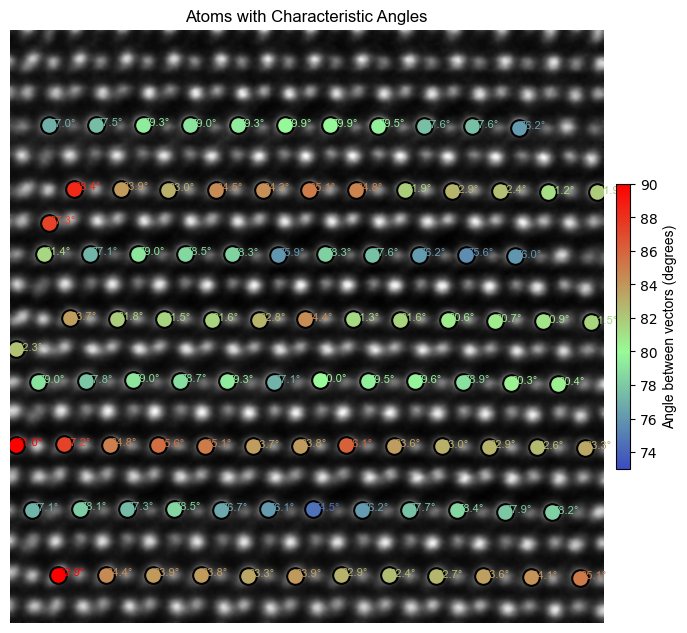

In [11]:
# Extract features and visualize atoms with characteristic angles (no single atom visualization)
features = extract_features(final_atoms, avg_nn_distance*2.2, plt_feature=0)

# Mark and display these features on the image with angle labels
mark_features_on_image(denoise_frame_i, features, plt_text=1, save_path=None)

# Sort features by the x-coordinate of atom positions
features = sorted(features, key=lambda item: item[0][0])

#### 4.2、Phase identify

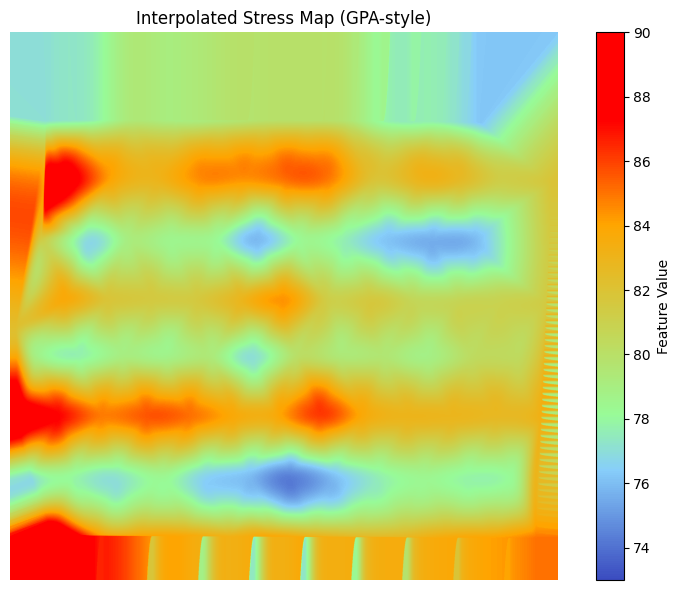

In [12]:
def fill_nan_nearest(data):
    """Fill NaN values using nearest non-NaN neighbors."""
    nan_mask = np.isnan(data)
    if np.all(nan_mask):
        raise ValueError("All values are NaN")
    filled = data.copy()
    # Get indices of nearest non-NaN pixels
    ind = distance_transform_edt(nan_mask, return_distances=False, return_indices=True)
    filled[nan_mask] = data[tuple(ind[:, nan_mask])]
    return filled

# Get image size (width, height)
width, height = denoise_frame_i.size  # denoise_frame_i is a PIL Image

# Extract positions and feature values from features list
positions = np.array([pos for pos, _ in features])
values = np.array([val for _, val in features])

# Create grid coordinates for interpolation
grid_x, grid_y = np.meshgrid(np.arange(width), np.arange(height))

# Interpolate feature values over the grid ('cubic' for smooth interpolation)
grid_z = griddata(positions, values, (grid_x, grid_y), method='cubic', fill_value=np.nan)

# Fill NaNs from interpolation with nearest valid value
grid_z_filled = fill_nan_nearest(grid_z)

# Define custom color map and normalization
colors = [
    (0, "#3B4CC0"),
    (0.2, "#87CEFA"),
    (0.3, "#98FB98"),
    (0.65, "orange"),
    (0.84, "red"),
    (1, "red")
]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)
norm = plt.Normalize(vmin=73, vmax=90)

# Plot interpolated feature map
plt.figure(figsize=(8, 6))
img = plt.imshow(grid_z_filled, cmap=cmap, norm=norm, origin='upper')
plt.colorbar(img, label='Feature Value')
plt.title("Interpolated Stress Map (GPA-style)")
plt.axis('off')
plt.tight_layout()

# Save high-resolution figure
plt.savefig(save_img_path, dpi=300, bbox_inches='tight')
plt.show()

# Supply： For video frame load

In [10]:
def read_frame_i(video_path, frame_number, mask=None):
    """
    Read a specific frame from a video file, convert to grayscale, optionally apply a mask, 
    and return it as a PIL Image. Also displays the grayscale frame.

    Args:
        video_path (str): Path to the video file.
        frame_number (int): The frame index to read.
        mask (list or None): Optional list of pixel indices (or slices) to zero out in the frame.

    Returns:
        PIL.Image or None: The processed grayscale frame as a PIL Image, or None if reading fails.
    """
    # Open video file
    cap = cv2.VideoCapture(video_path)
    
    # Check if video opened successfully
    if not cap.isOpened():
        print("Unable to open video file")
        return
    
    # Set the video to the target frame number
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    
    # Read the specified frame
    ret, frame = cap.read()
    if ret:
        # Convert the frame to grayscale
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Apply mask if provided: set masked pixels to zero
        if mask is not None:
            for regioni in mask:
                gray_frame[regioni] = 0
        
        # Convert the grayscale frame to a PIL Image
        pil_image = Image.fromarray(gray_frame)
        
        # Display the grayscale image
        plt.imshow(pil_image, cmap='gray')
        plt.show()
        
        # Release video resource
        cap.release()
        
        return pil_image
    else:
        # If frame reading failed
        print(f"Unable to read frame number {frame_number}")
        cap.release()
        return None